In [1]:
import pandas as pd
import numpy as np

from datetime import timedelta

import geopandas as gpd
import movingpandas as mpd

import datashader as ds
import datashader.transfer_functions as ds_function
from datashader.utils import export_image
from functools import partial
import colorcet as cc

c:\Users\ongai\Desktop\FYP\.venv\Lib\site-packages\movingpandas\__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [ ]:
ais_stream_API = "69b4c37ea42da6820a2c6674efa59d6cbef99015"

In [2]:
data = pd.read_csv("vessel_movements_PPT.csv")

In [21]:
data.head()

,imo,mmsi,vessel_id,vessel_name,date_of_build,vessel_type,group,timestamp,date_only,lon,...,anchorage,terminal,maneuvering_zone,p,vref,sfc_me,sfc_ae,sfc_ab,ael,abl
0,9223253,525119038,692017,PRIMA TANGGUH LVI,2002-04-01,Crude/Oil Products Tanker,Crude & Products Tanker,2023-09-17T00:01:42.000Z,2023-09-17,103.826065,...,PPT Anchorage,NaN,NaN,7860.0,14.5,185.0,230.0,300.0,507.0,365.0
1,9223253,525119038,692017,PRIMA TANGGUH LVI,2002-04-01,Crude/Oil Products Tanker,Crude & Products Tanker,2023-09-17T00:01:44.000Z,2023-09-17,103.826065,...,PPT Anchorage,NaN,NaN,7860.0,14.5,185.0,230.0,300.0,507.0,365.0
2,9223253,525119038,692017,PRIMA TANGGUH LVI,2002-04-01,Crude/Oil Products Tanker,Crude & Products Tanker,2023-09-17T00:07:43.000Z,2023-09-17,103.825690,...,PPT Anchorage,NaN,NaN,7860.0,14.5,185.0,230.0,300.0,507.0,365.0
3,9223253,525119038,692017,PRIMA TANGGUH LVI,2002-04-01,Crude/Oil Products Tanker,Crude & Products Tanker,2023-09-17T00:07:45.000Z,2023-09-17,103.825690,...,PPT Anchorage,NaN,NaN,7860.0,14.5,185.0,230.0,300.0,507.0,365.0
4,9223253,525119038,692017,PRIMA TANGGUH LVI,2002-04-01,Crude/Oil Products Tanker,Crude & Products Tanker,2023-09-17T00:10:42.000Z,2023-09-17,103.825580,...,PPT Anchorage,NaN,NaN,7860.0,14.5,185.0,230.0,300.0,507.0,365.0


In [26]:
data['mmsi'].nunique()

2792

In [28]:
data.columns

Index(['imo', 'mmsi', 'vessel_id', 'vessel_name', 'date_of_build',
       'vessel_type', 'group', 'timestamp', 'date_only', 'lon', 'lat',
       'nav_stat', 'speed', 'course', 'heading', 'fuel_category',
       'main_engine_fuel_type', 'aux_engine_fuel_type', 'engine_type', 'berth',
       'port_name', 'coverage', 'anchorage', 'terminal', 'maneuvering_zone',
       'p', 'vref', 'sfc_me', 'sfc_ae', 'sfc_ab', 'ael', 'abl'],
      dtype='object')

In [27]:
# let's get 200 vessels
seed = 200
array = data['mmsi'].unique()[:seed]

# create a subset of data
subset = data[data['mmsi'].isin(array)]

In [29]:
subset_columns = subset[['mmsi','vessel_name','lat','lon','timestamp','speed','vessel_type']]

In [30]:
# let's create a geodataframe
geodata = gpd.GeoDataFrame(subset_columns,
                          geometry = gpd.points_from_xy(x=subset_columns['lon'],
                                                        y=subset_columns['lat']),
                           crs = 'wgs84')

In [31]:
print(f"Original number of ships: {geodata['mmsi'].nunique()}")
geodata = geodata[geodata["speed"] > 0]
print(f"Reduced to {geodata['mmsi'].nunique()} ships after removing 0 speed records")

Original number of ships: 200
Reduced to 200 ships after removing 0 speed records


## Trajectories
A TrajectoryCollection object is created from the AIS data, applying a filter to exclude trajectories shorter than 100 meters. This step ensures that only meaningful ship movements are retained for analysis, removing short or potentially noisy trajectories that are not relevant.

In [32]:
# create a column with timestamp format
geodata["t"] = pd.to_datetime(geodata["timestamp"], format="%Y-%m-%dT%H:%M:%S.%fZ")

del geodata['timestamp']

# create a traj collection using movingpandas
traj_collection = mpd.TrajectoryCollection(geodata, "mmsi", t="t", min_length=100)


print(f"Finished creating {len(traj_collection)} trajectories")

c:\Users\ongai\Desktop\FYP\.venv\Lib\site-packages\geographiclib\geodesic.py:668: RuntimeWarning: coroutine 'connect_ais_stream' was never awaited
  sig12 = math.atan2(max(0.0, csig1 * ssig2 - ssig1 * csig2) + 0.0,


Finished creating 200 trajectories


In [33]:
# add a filter generalization of 10 mins per delta
traj_collection = mpd.MinTimeDeltaGeneralizer(traj_collection).generalize(
    tolerance=timedelta(minutes=5),
)

In [34]:
# check a table
for traj in traj_collection:

    print(traj.df.head())
    break

                          mmsi vessel_name       lat         lon  speed  \
t                                                                         
2023-09-17 15:30:41  209370000    ST. MARY  1.208768  103.818530   12.0   
2023-09-17 15:40:02  209370000    ST. MARY  1.225478  103.792210   10.0   
2023-09-17 15:45:02  209370000    ST. MARY  1.235155  103.784710    7.0   
2023-09-17 15:50:02  209370000    ST. MARY  1.243553  103.778370    7.0   
2023-09-17 15:55:02  209370000    ST. MARY  1.251472  103.771835    7.0   

                                         vessel_type  \
t                                                      
2023-09-17 15:30:41  Container Ship (Fully Cellular)   
2023-09-17 15:40:02  Container Ship (Fully Cellular)   
2023-09-17 15:45:02  Container Ship (Fully Cellular)   
2023-09-17 15:50:02  Container Ship (Fully Cellular)   
2023-09-17 15:55:02  Container Ship (Fully Cellular)   

                                      geometry  
t                               

## LineStrings
Let's make the trajectories LineStrings to add them as a background in the KeplerGI visualization. The function from movingpandas is to_line_gdf()

In [ ]:
# get linestrings
line_traj = traj_collection.to_line_gdf()

# get a simple dataframe
line_vis = line_traj[['vessel_type', 'geometry', 'vessel_name','t']].dropna()

In [37]:
# ------ To Kepler --------- 

line_vis.to_file('line_vis_kepler_200.geojson')

## Points
We transform the trajectories into points using the movingpandas function to_point_gdf()

In [ ]:
# get points from trajectories
point_traj =  traj_collection.to_point_gdf()

# get index 
point_traj_t = point_traj.reset_index(drop=False)

# get a simple dataframe
point_vis = point_traj_t[['lat', 'lon', 't', 'vessel_name','vessel_type']]

Switch the datetime to a timestamp Unix format, and add a string to the trip id previously MMSI

In [40]:
# add timestamp and traj id
point_vis = point_vis.copy()

point_vis["timestamp_unix"] = point_traj_t['t'].astype(np.int64) // 10**9
point_vis['trip_id'] = point_traj_t['mmsi']

del point_vis['t']

point_vis['trip_id'] = ['mmsi-'+str(value) for value in point_vis['trip_id']]

In [43]:
point_vis.head()

,lat,lon,vessel_type,timestamp_unix,trip_id
0,1.208768,103.818530,Container Ship (Fully Cellular),1694964641,mmsi-209370000
1,1.225478,103.792210,Container Ship (Fully Cellular),1694965202,mmsi-209370000
2,1.235155,103.784710,Container Ship (Fully Cellular),1694965502,mmsi-209370000
3,1.243553,103.778370,Container Ship (Fully Cellular),1694965802,mmsi-209370000
4,1.251472,103.771835,Container Ship (Fully Cellular),1694966102,mmsi-209370000


In [44]:
# ------ To Kepler --------- 

point_vis.to_csv('point_vis_kepler_200.csv', index=False)

In [48]:
point_vis["vessel_type"].nunique()

23

## Heat Map Visualisation
We use Datashader to generate a spatially aggregated visualization of the GPS records, incorporating the entire AIS dataset to identify patterns in vessel density and movement.

In [6]:
print(f"Original number of ships: {data['mmsi'].nunique()}")
data = data[data["speed"] > 0]
print(f"Reduced to {data['mmsi'].nunique()} ships after removing 0 speed records")

Original number of ships: 2751
Reduced to 2751 ships after removing 0 speed records


In [11]:
print(min(data['lon']),max(data['lon']))
print(min(data['lat']),max(data['lat']))

103.74166 103.829414
1.2050784 1.2929584


In [10]:
# let's create a geodataframe
data_gdf = gpd.GeoDataFrame(data,
                          geometry = gpd.points_from_xy(x=data['lon'],
                                                        y=data['lat']),
                           crs = 'wgs84')

In [12]:
# clip boundaries

# (minx, miny, maxx, maxy)
coor = (103.739, 1.203, 103.831, 1.293)
data_bound = gpd.clip(data_gdf, mask=coor, keep_geom_type=False)

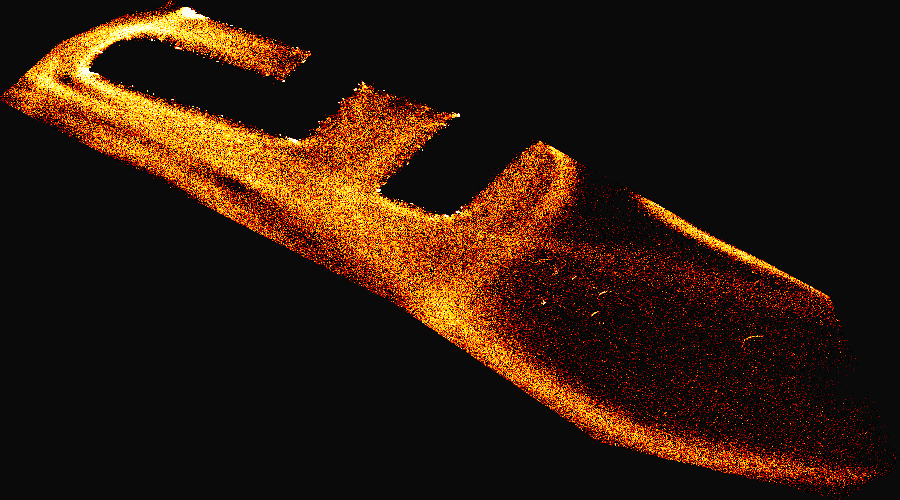

In [14]:
# canvas object
canvas = ds.Canvas(plot_width=900, plot_height=500)

# variable columns aggregation like agg=ds.max("column-name")
agg = canvas.points(data_bound, 'lon', 'lat', agg=ds.count())

# image shade with a distribution like ‘eq_hist’ [default], ‘cbrt’ (cube root), ‘log’ (logarithmic), and ‘linear’
# cmaps like fire, kb, kr, kg, bgyw

im = ds_function.shade(agg, cmap=cc.fire, how="eq_hist")
ds_function.set_background(im, "#0A0A0A")

# save
export = partial(export_image, background = "#0A0A0A", export_path='output')
export(im, 'ais_vis_datashader')